In [1]:
import cv2
import numpy as np
import gmsh
import pyvista as pv
import upxo._sup.data_ops as DO
from copy import deepcopy
from shapely import affinity
from upxo.geoEntities.mulsline2d import MSline2d
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter
from meshpy.triangle import MeshInfo, build
from upxo.ggrowth.mcgs import mcgs
from upxo.geoEntities.mulsline2d import MSline2d
from shapely.geometry import Point
from shapely.geometry import MultiPolygon, Point
from scipy.spatial import cKDTree
from shapely.geometry import Point
from upxo.geoEntities.mulsline2d import ring2d
from upxo._sup.data_ops import find_common_coordinates
from shapely.geometry import LineString, MultiLineString
from upxo.geoEntities.point2d import Point2d
from upxo.geoEntities.mulpoint2d import MPoint2d
from shapely.geometry import Point as ShPoint2d
from upxo._sup.data_ops import remove_2d_child_array_from_2d_parent_array

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs
c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs\input_dashboard.xls
Algo_hops details
(('201.0', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 200.0, 1.0
     ymin, ymax, yinc: 0.0, 200.0, 1.0
     zmin, zmax, zinc: 0.0, 50.0, 1.0
     No. of states: 10
     Dimensionality: 2
     Algorithm: 201.0 





########################################
201.0
########################################
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
 ..............................
GS temporal slice 1 stored
 ..............................
GS temporal slice 2 stored
 ..............................
GS temporal slice 3 stored
 ..............................
GS temporal slice 4 stored
 ..............................
GS temporal slice 5 stored
 

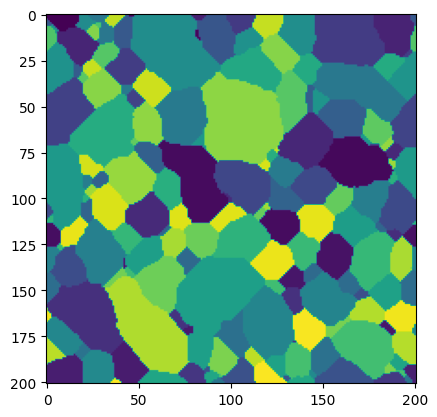

In [2]:
pxt = mcgs()
pxt.simulate()
pxt.detect_grains()
tslice = 25
gstslice = pxt.gs[tslice]
# pxt.char_morph_2d(tslice)
gstslice.char_morph_2d(bbox=True, bbox_ex=True, npixels=False,
                              npixels_gb=False, area=True, eq_diameter=True,
                              perimeter=True, perimeter_crofton=True,
                              compactness=True, gb_length_px=False,
                              aspect_ratio=True,
                              solidity=True, morph_ori=False,
                              circularity=False,
                              eccentricity=False, feret_diameter=True,
                              major_axis_length=False, minor_axis_length=False,
                              euler_number=False, append=False, saa=True,
                              throw=False, char_grain_positions=False,
                              find_neigh=False, char_gb=True,
                              make_skim_prop=True, get_grain_coords=False)
gstslice.find_neigh()
# --------------------------------------------------------------------
gstslice.remove_single_pixel_grains(acceptable_percentage_fraction=0)
gstslice.remove_straight_line_grains(acceptable_percentage_fraction=0)
plt.imshow(gstslice.lgi)

In [3]:
gstslice.find_grain_boundary_junction_points()
folder, fileName = r'D:\export_folder', 'sunil'
gstslice.export_ctf(folder, fileName, factor=1, method='nearest')
fname = r'D:\export_folder\sunil'
gstslice.set_pxtal(instance_no=1, path_filename_noext=fname)

CTF header read successful
Header lines creation successful.
Phase name set to PHNAME.
Coordinate grid setup successfull.
State set successfull.
Setting state-mapped random field data specification.
Field data specification succeffsul.
D:\export_folder\sunil.ctf
D:\export_folder\sunil
Loaded EBSD data (dimensions: 201 x 201 pixels, step size: 1.0 um)
Finished building quaternion array (0:00:00) 
---------------------------------------- 
 Finding boundaries.
Finished finding grain boundaries (0:00:00) 
---------------------------------------- 
 Finding grains.
Finished finding grains (0:00:00) 
---------------------------------------- 
 Building neighbourhood network.
Finished constructing neighbour network (0:00:00) 
---------------------------------------- 
 Porting essential data to UPXO.
---------------------------------------- 
 Calculating morphological properties.
Success.
---------------------------------------- 
 MCGS2d-XOMAP conversion loss: -0.55 %


In [4]:
gstslice.pxtal[1].find_gbseg1()
gstslice.pxtal[1].gbseg1
gstslice.pxtal[1].extract_gb_discrete(retrieval_method='external', chain_approximation='simple')
gstslice.pxtal[1].set_geom()

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\rasterio\io.py:141: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  return writer(


In [5]:
from upxo.pxtal.geometrification import polygonised_grain_structure as pgs
geom = pgs(gstslice.pxtal[1].lgi, gstslice.pxtal[1].gid, gstslice.pxtal[1].neigh_gid)
geom.set_up_quality_measures()
# geom.n
# gstslice.pxtal[1].n
geom.polygonize()
# geom.raster_img_polygonisation_results
geom.set_polygonization_xyoffset(0.5)
geom.make_polygonal_grains_raw()
geom.set_polygons()
geom.make_gsmp()
geom.find_neighbors()
geom.set_grain_centroids_raw()
geom.set_grain_loc_ids()
# geom.plot_gsmp(raw=True, overlay_on_lgi=True, xoffset=0.5, yoffset=0.5)
geom.gbops()
geom.consolidated_segments[1]
geom.sorted_segs[1]
gbsegs_can_form_rings, _ = geom.check_if_all_gbsegs_can_form_closed_rings(geom.consolidated_segments,
                                                                          _print_individual_excoord_order_=False,
                                                                          _print_statement_=True)
gbsegs_can_form_rings, _ = geom.check_if_all_gbsegs_can_form_closed_rings(geom.sorted_segs,
                                                                          _print_individual_excoord_order_=False,
                                                                          _print_statement_=True)

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\rasterio\io.py:141: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  return writer(
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\rasterio\io.py:141: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  return writer(


Extracting Junction points 27.17 % complete.
Extracting Junction points 54.35 % complete.
Extracting Junction points 81.52 % complete.
Grain boundary segmentation quality measure 1: 100.0 %
Constructing grain neigh pair ID keyed and gbseg valued dictionary
Consolidating grain boundary segment database.
----------------------------------------
gid=1:  gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continous. N.Segs=5. N.Iterations=6
----------------------------------------
gid=2:  gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continous. N.Segs=7. N.Iterations=8
----------------------------------------
gid=3:  gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continous. N.Segs=6. N.Iterations=7
----------------------------------------
gid=4:  gbsegs not continuous. Attempting reorder.
Re-ordering success. gbsegs are continous. N.Segs=7. N.Iterations=8
----------------------------------------
gid=5:  gbsegs 

In [6]:
geom.smooth_gbsegs(geom.GB, npasses=2, max_smooth_levels=[3, 3], plot=False, seriesname='kali')
geom.smooth_gbsegs(geom.smoothed['kali.1']['GB'], npasses=2, max_smooth_levels=[3, 3], plot=False)

Carrying out smoothing pass: 1
Carrying out smoothing pass: 2
Carrying out smoothing pass: 1
Carrying out smoothing pass: 2


In [7]:
geom.smoothed.keys()

dict_keys(['kali.1', 'kali.2'])

In [8]:
geom.smoothed['kali.1'].keys()

dict_keys(['GB', 'GBCoords', 'GRAINS', 'POLYXTAL'])

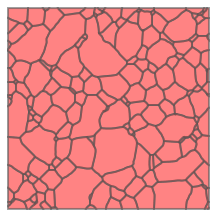

In [9]:
geom.smoothed['kali.1']['POLYXTAL']

In [10]:
geom.smoothed['kali.1']['GB']

{1: UPXO ring. nseg=5. MID: 1775955172512,
 2: UPXO ring. nseg=7. MID: 1776058001920,
 3: UPXO ring. nseg=6. MID: 1776058109184,
 4: UPXO ring. nseg=7. MID: 1776058332640,
 5: UPXO ring. nseg=7. MID: 1776058465056,
 6: UPXO ring. nseg=9. MID: 1776058589088,
 7: UPXO ring. nseg=2. MID: 1776058967040,
 8: UPXO ring. nseg=3. MID: 1776058967520,
 9: UPXO ring. nseg=6. MID: 1776058968096,
 10: UPXO ring. nseg=6. MID: 1776059096704,
 11: UPXO ring. nseg=4. MID: 1776059222528,
 12: UPXO ring. nseg=5. MID: 1776059345216,
 13: UPXO ring. nseg=4. MID: 1776059470176,
 14: UPXO ring. nseg=4. MID: 1776059471328,
 15: UPXO ring. nseg=6. MID: 1776059473824,
 16: UPXO ring. nseg=5. MID: 1776059728608,
 17: UPXO ring. nseg=6. MID: 1776059850912,
 18: UPXO ring. nseg=2. MID: 1776059852160,
 19: UPXO ring. nseg=5. MID: 1776059852640,
 20: UPXO ring. nseg=3. MID: 1776059853600,
 21: UPXO ring. nseg=5. MID: 1776059978176,
 22: UPXO ring. nseg=8. MID: 1776059980480,
 23: UPXO ring. nseg=4. MID: 177606022499

In [11]:
geom.smoothed['kali.1']['GB'][1].assess_spatial_continuity()

(True, False, [(True, False), (True, False), (True, False), (True, False)])

<AxesSubplot: >

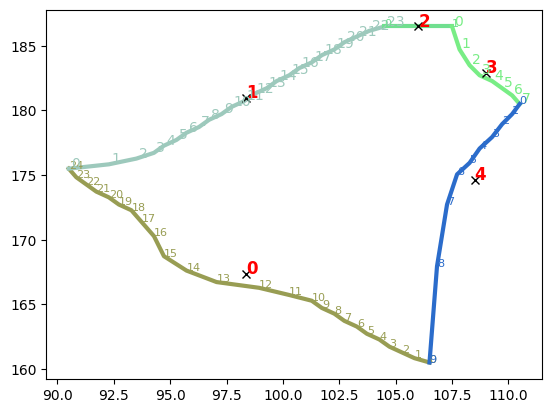

In [12]:
geom.smoothed['kali.1']['GB'][1].plot_segs()

In [13]:
geom.smoothed['kali.1']['GB'][1].segments

[MSL2. nln=24. ID: 1776048857664: uxpo-p2d (106.5,160.5), uxpo-p2d (90.5,175.5),
 MSL2. nln=23. ID: 1776057951808: uxpo-p2d (90.5,175.5), uxpo-p2d (104.5,186.5),
 MSL2. nln=1. ID: 1776058017024: uxpo-p2d (104.5,186.5), uxpo-p2d (107.5,186.5),
 MSL2. nln=7. ID: 1776058017600: uxpo-p2d (107.5,186.5), uxpo-p2d (110.5,180.5),
 MSL2. nln=9. ID: 1776058029824: uxpo-p2d (110.5,180.5), uxpo-p2d (106.5,160.5)]

<AxesSubplot: >

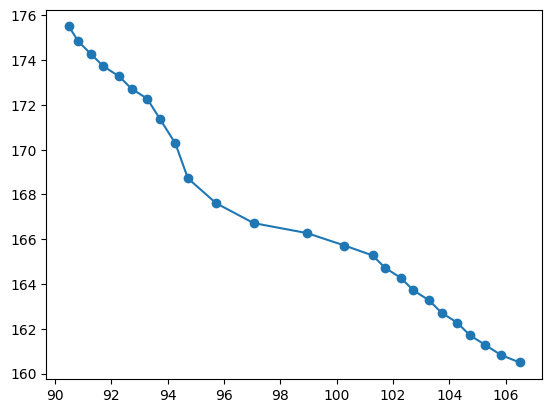

In [14]:
geom.smoothed['kali.1']['GB'][1].segments[0].plot()

In [15]:
geom.smoothed['kali.1']['GB'][1].segments[0].gradients

[-0.49999999999995737,
 -0.7999999999999693,
 -0.8000000000000409,
 -1.25000000000004,
 -0.7999999999999489,
 -1.25000000000008,
 -0.7999999999999489,
 -1.249999999999976,
 -0.8000000000000409,
 -1.25000000000004,
 -0.4444444444444223,
 -0.41666666666668,
 -0.23529411764705085,
 -0.6666666666666595,
 -1.11111111111113,
 -3.500000000000048,
 -1.9999999999998976,
 -2.000000000000128,
 -0.7999999999999693,
 -1.249999999999976,
 -0.8000000000000205,
 -1.25000000000004,
 -1.249999999999936,
 -2.0000000000001705]

In [16]:
geom.smoothed['kali.1']['GB'][1].segments[0].extract_nodes()

[uxpo-p2d (106.5,160.5),
 uxpo-p2d (105.83333333333331,160.83333333333331),
 uxpo-p2d (105.27777777777776,161.27777777777774),
 uxpo-p2d (104.72222222222221,161.7222222222222),
 uxpo-p2d (104.27777777777777,162.27777777777777),
 uxpo-p2d (103.7222222222222,162.7222222222222),
 uxpo-p2d (103.27777777777777,163.27777777777777),
 uxpo-p2d (102.7222222222222,163.7222222222222),
 uxpo-p2d (102.27777777777776,164.27777777777774),
 uxpo-p2d (101.72222222222221,164.7222222222222),
 uxpo-p2d (101.27777777777777,165.27777777777777),
 uxpo-p2d (100.27777777777776,165.7222222222222),
 uxpo-p2d (98.94444444444443,166.27777777777777),
 uxpo-p2d (97.05555555555554,166.7222222222222),
 uxpo-p2d (95.7222222222222,167.6111111111111),
 uxpo-p2d (94.72222222222221,168.7222222222222),
 uxpo-p2d (94.27777777777777,170.27777777777777),
 uxpo-p2d (93.7222222222222,171.38888888888886),
 uxpo-p2d (93.27777777777777,172.27777777777777),
 uxpo-p2d (92.72222222222221,172.7222222222222),
 uxpo-p2d (92.2777777777777

In [17]:
geom.smoothed['kali.1']['GB'][1].segments[0].get_nodes

array([[ 90.5       , 175.5       ],
       [ 90.83333333, 174.83333333],
       [ 91.27777778, 174.27777778],
       [ 91.72222222, 173.72222222],
       [ 92.27777778, 173.27777778],
       [ 92.72222222, 172.72222222],
       [ 93.27777778, 172.27777778],
       [ 93.72222222, 171.38888889],
       [ 94.27777778, 170.27777778],
       [ 94.72222222, 168.72222222],
       [ 95.72222222, 167.61111111],
       [ 97.05555556, 166.72222222],
       [ 98.94444444, 166.27777778],
       [100.27777778, 165.72222222],
       [101.27777778, 165.27777778],
       [101.72222222, 164.72222222],
       [102.27777778, 164.27777778],
       [102.72222222, 163.72222222],
       [103.27777778, 163.27777778],
       [103.72222222, 162.72222222],
       [104.27777778, 162.27777778],
       [104.72222222, 161.72222222],
       [105.27777778, 161.27777778],
       [105.83333333, 160.83333333],
       [106.5       , 160.5       ]])

In [18]:
geom.smoothed['kali.1']['GB'][1].segments[0].get_node_coords()

array([[106.5       , 160.5       ],
       [105.83333333, 160.83333333],
       [105.27777778, 161.27777778],
       [104.72222222, 161.72222222],
       [104.27777778, 162.27777778],
       [103.72222222, 162.72222222],
       [103.27777778, 163.27777778],
       [102.72222222, 163.72222222],
       [102.27777778, 164.27777778],
       [101.72222222, 164.72222222],
       [101.27777778, 165.27777778],
       [100.27777778, 165.72222222],
       [ 98.94444444, 166.27777778],
       [ 97.05555556, 166.72222222],
       [ 95.72222222, 167.61111111],
       [ 94.72222222, 168.72222222],
       [ 94.27777778, 170.27777778],
       [ 93.72222222, 171.38888889],
       [ 93.27777778, 172.27777778],
       [ 92.72222222, 172.72222222],
       [ 92.27777778, 173.27777778],
       [ 91.72222222, 173.72222222],
       [ 91.27777778, 174.27777778],
       [ 90.83333333, 174.83333333],
       [ 90.5       , 175.5       ]])

In [19]:
geom.smoothed['kali.1']['GB'][1].segments[0].lengths

[0.7453559924999384,
 0.7114582486036413,
 0.7114582486036478,
 0.7114582486036611,
 0.7114582486036523,
 0.7114582486036523,
 0.7114582486036523,
 0.7114582486036389,
 0.7114582486036478,
 0.7114582486036611,
 1.0943175335329072,
 1.4444444444444462,
 1.9404721329525467,
 1.602467233539557,
 1.4948471163415162,
 1.6178021976179076,
 1.2422599874998677,
 0.993807989999922,
 0.7114582486036413,
 0.7114582486036389,
 0.711458248603659,
 0.7114582486036611,
 0.7114582486036478,
 0.7453559924999384]

In [20]:
geom.smoothed['kali.1']['GB'][1].segments[0].features

{'neigh_gids': None}

In [21]:
geom.smoothed['kali.1']['GB'][1].segments[0].coords

array([[106.5       , 160.5       ],
       [105.83333333, 160.83333333],
       [105.27777778, 161.27777778],
       [104.72222222, 161.72222222],
       [104.27777778, 162.27777778],
       [103.72222222, 162.72222222],
       [103.27777778, 163.27777778],
       [102.72222222, 163.72222222],
       [102.27777778, 164.27777778],
       [101.72222222, 164.72222222],
       [101.27777778, 165.27777778],
       [100.27777778, 165.72222222],
       [ 98.94444444, 166.27777778],
       [ 97.05555556, 166.72222222],
       [ 95.72222222, 167.61111111],
       [ 94.72222222, 168.72222222],
       [ 94.27777778, 170.27777778],
       [ 93.72222222, 171.38888889],
       [ 93.27777778, 172.27777778],
       [ 92.72222222, 172.72222222],
       [ 92.27777778, 173.27777778],
       [ 91.72222222, 173.72222222],
       [ 91.27777778, 174.27777778],
       [ 90.83333333, 174.83333333],
       [ 90.5       , 175.5       ]])